In [9]:
#Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
#Step 2: Load the Cleaned Dataset

In [2]:
df = pd.read_csv("../Cleaned_Data/HR_Cleaned.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,ExperienceGroup,IncomeCategory,AttritionFlag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,1,6,4,0,5,Middle-aged,6-10 Years,Medium,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,3,10,7,1,7,Senior,6-10 Years,Medium,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,3,0,0,0,0,Middle-aged,6-10 Years,Low,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,8,7,3,0,Middle-aged,6-10 Years,Low,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,3,2,2,2,2,Young,6-10 Years,Low,0


In [11]:
#Step 3: Total Employees

In [4]:
total_employees = df.shape[0]
print("Total Employees:", total_employees)

Total Employees: 1470


In [12]:
#Step 4: Attrition Count

In [5]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [13]:
#Step 5: Attrition Rate

In [7]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [15]:
#Step 6: Department-wise Attrition

In [16]:
dept_attrition = df.groupby("Department")["AttritionFlag"].sum()

print(dept_attrition)

Department
Human Resources            12
Research & Development    133
Sales                      92
Name: AttritionFlag, dtype: int64


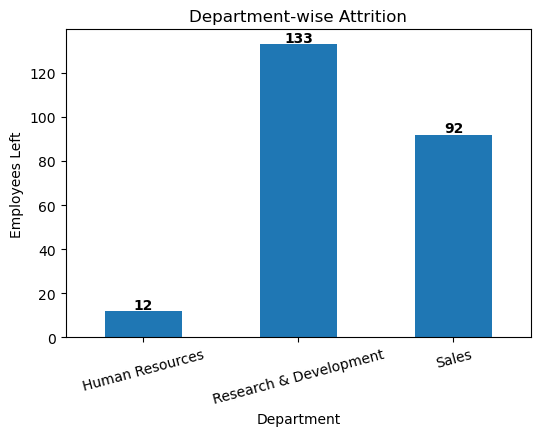

In [18]:
import matplotlib.pyplot as plt

# Department-wise attrition
dept_attrition = df.groupby("Department")["AttritionFlag"].sum()

# Create plot
ax = dept_attrition.plot(kind="bar", figsize=(6,4))

# Add value labels on top of bars
for i, value in enumerate(dept_attrition):
    ax.text(i, value + 1, str(value), ha='center', fontweight='bold')

plt.title("Department-wise Attrition")
plt.xlabel("Department")
plt.ylabel("Employees Left")
plt.xticks(rotation=15)
plt.show()

In [21]:
#Step 7: Attrition by Gender

In [22]:
gender_attrition = pd.crosstab(
    df["Gender"],
    df["Attrition"]
)

print(gender_attrition)

Attrition   No  Yes
Gender             
Female     501   87
Male       732  150


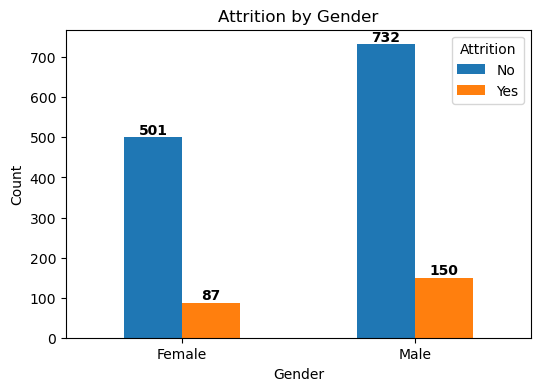

In [24]:
gender_attrition = pd.crosstab(df["Gender"], df["Attrition"])

ax = gender_attrition.plot(kind="bar", figsize=(6,4))

# Add exact values on each bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

plt.title("Attrition by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [25]:
#Step 8: Attrition by Age Group

In [26]:
age_attrition = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"]
)

print(age_attrition)

Attrition     No  Yes
AgeGroup             
Middle-aged  708  103
Senior       239   34
Young        286  100


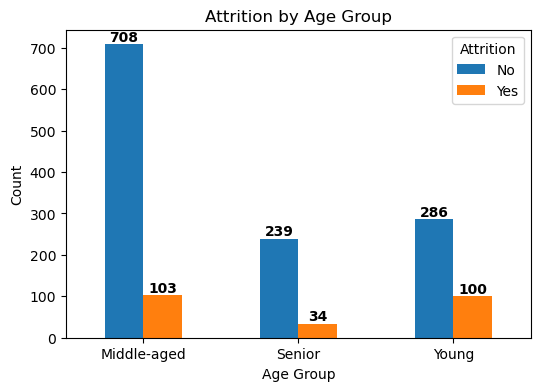

In [28]:
ax = age_attrition.plot(kind="bar", figsize=(6,4))

# Add exact values on each bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [29]:
#Step 9: Overtime vs Attrition ⭐ Important

In [30]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

print(overtime_attrition)

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


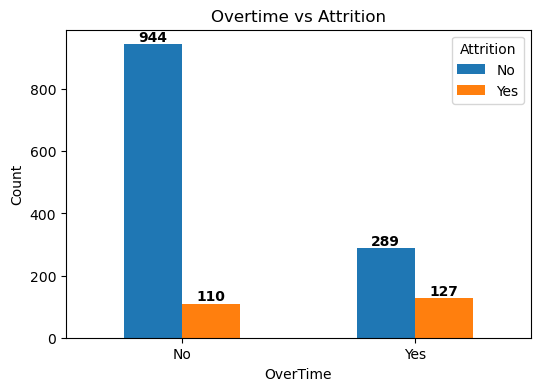

In [32]:
ax = overtime_attrition.plot(kind="bar", figsize=(6,4))

# Add exact values on each bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

plt.title("Overtime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [33]:
#Step 10: Average Salary by Department

In [34]:
avg_salary = df.groupby("Department")["MonthlyIncome"].mean()

print(avg_salary)

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64


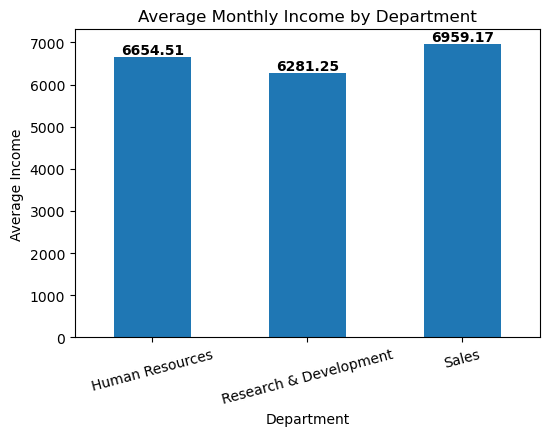

In [35]:
ax = avg_salary.plot(kind="bar", figsize=(6,4))

# Add exact values on each bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')
plt.title("Average Monthly Income by Department")
plt.xlabel("Department")
plt.ylabel("Average Income")
plt.xticks(rotation=15)
plt.show()

In [36]:
#Step 11: Job Satisfaction Distribution

In [37]:
job_satisfaction = df["JobSatisfaction"].value_counts().sort_index()

print(job_satisfaction)

JobSatisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64


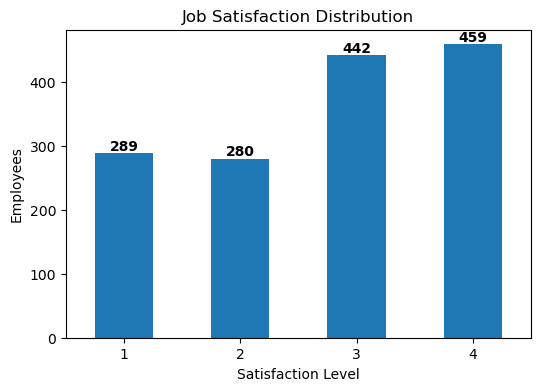

In [38]:
ax = job_satisfaction.plot(kind="bar", figsize=(6,4))

# Add exact values on each bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

plt.title("Job Satisfaction Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Employees")
plt.xticks(rotation=0)
plt.show()

In [39]:
#Step 12: Top 10 Highest Paid Employees

In [40]:
top_salary = df.nlargest(10, "MonthlyIncome")[
    ["JobRole", "Department", "MonthlyIncome"]
]

print(top_salary)

                JobRole              Department  MonthlyIncome
190             Manager  Research & Development          19999
746   Research Director  Research & Development          19973
851             Manager  Research & Development          19943
165             Manager  Research & Development          19926
568             Manager  Research & Development          19859
918             Manager                   Sales          19847
749             Manager                   Sales          19845
1242            Manager                   Sales          19833
898   Research Director  Research & Development          19740
956             Manager         Human Resources          19717
